In [1]:
import importlib
import sys
import numpy as np

# performance imports for torch: torch kernel uses one core only.
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["TORCH_NUM_THREADS"] = "1" 

import torch

sys.path.insert(0, '..')
sys.path.insert(0, '../..')
sys.path.insert(0, '../../..')
sys.path.insert(0, '../../../..')

In [2]:

import data_processing.labeling_encoding
importlib.reload(data_processing.labeling_encoding)
from data_processing.labeling_encoding import PrefixesDataFrameLoader, EventLogLoader

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

np.random.seed(17)

event_log_location = '../../../simulator/procurement_event_log.csv'

result_name = 'procurement_all'

# dynamic categorical attributes (change within a trace)
cat_dynamic = ['concept:name',
               'org:resource',
               'budget_status',
               'supplier_type',
               'goods_match']

# static categorical attributes (fixed per trace, vary across cases)
cat_static = ['requester_seniority',
              'department',
              'category',
              'priority']

# dynamic numerical attributes (change within a trace)
num_dynamic = ['case_elapsed_time',
               'event_elapsed_time',
               'day_in_week',
               'seconds_in_day',
               'amount',
               'revision_count',
               'invoice_deviation_pct']
num_dyn_log = []

# static numeric attributes
num_static = []

min_suffix_size = 5

# 20% test size:
test_validation_size = 0.2

event_log_properties = {# case id
                        'case_name' : 'case:concept:name',
                        # activity
                        'concept_name' : 'concept:name',
                        # time values and computaitons
                        'timestamp_name' : 'time:timestamp',
                        # simulator outputs: 2025-01-01 08:00:00.000000
                        'date_format' : '%Y-%m-%d %H:%M:%S.%f',
                        'time_since_case_start_column' : 'case_elapsed_time',
                        'time_since_last_event_column' : 'event_elapsed_time',
                        'day_in_week_column' : 'day_in_week',
                        'seconds_in_day_column' : 'seconds_in_day',
                        # min suffix size for eos padding right
                        'min_suffix_size' : min_suffix_size,
                        # train and test split
                        'train_validation_size' : 0.15,
                        'test_validation_size' : test_validation_size,
                        # window size for padding
                        'window_size' : 'auto',
                        # dynamic and static values
                        'categorical_columns' : cat_dynamic,
                        'static_categorical_columns' : cat_static,
                        'continuous_columns' : num_dynamic,
                        'continuous_positive_columns' : num_dyn_log,
                        'static_continuous_columns' : num_static}


## Create dataframes of prefixes

In [3]:
# object to create datframe of prefixes for petri-net repaly marking computation
pref_adopt_dataframe = PrefixesDataFrameLoader(event_log_location=event_log_location, event_log_properties=event_log_properties)

In [4]:
# output if necessary the raw dataframe: dynamic are lists, static values
raw_data = pref_adopt_dataframe.get_raw_dataframe()
raw_data

,case:concept:name,concept:name,org:resource,budget_status,supplier_type,goods_match,case_elapsed_time,event_elapsed_time,day_in_week,seconds_in_day,amount,revision_count,invoice_deviation_pct,requester_seniority,department,category,priority
0,C00001,"[Create Purchase Requisition, Approve Requisit...","[Carol, Manager_FIN_1, Buyer_1, Buyer_1, Buyer...","[approved, approved, approved, approved, appro...","[nan, nan, nan, nan, risky, risky, risky, risk...","[nan, nan, nan, nan, nan, nan, nan, True, True...","[0.0, 97200.0, 158400.0, 190800.0, 302400.0, 3...","[nan, 97200.0, 61200.0, 32400.0, 111600.0, 288...","[2, 3, 4, 4, 5, 6, 6, 0, 0, 1, 2]","[28800, 39600, 14400, 46800, 72000, 14400, 828...","[5389.54, 5389.54, 5389.54, 5389.54, 5389.54, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]","[nan, nan, nan, nan, nan, nan, nan, nan, 0.052...",junior,Finance,office,critical
1,C00002,"[Create Purchase Requisition, Approve Requisit...","[Eva, Manager_OPS_1, Buyer_2, Buyer_2, Buyer_2...","[approved, approved, approved, approved, appro...","[nan, nan, nan, nan, risky, risky, risky, risk...","[nan, nan, nan, nan, nan, nan, nan, False, Fal...","[0.0, 54000.0, 111600.0, 147600.0, 176400.0, 2...","[nan, 54000.0, 57600.0, 36000.0, 28800.0, 2520...","[2, 2, 3, 4, 4, 4, 5, 6, 1, 2, 3]","[30360, 84360, 55560, 5160, 33960, 59160, 3396...","[3566.97, 3566.97, 3566.97, 3566.97, 3566.97, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]","[nan, nan, nan, nan, nan, nan, nan, nan, 0.075...",junior,Operations,consulting,critical
2,C00003,"[Create Purchase Requisition, Approve Requisit...","[Alice, Manager_IT_1, Buyer_2, Buyer_2, Buyer_...","[approved, approved, approved, approved, appro...","[nan, nan, nan, nan, risky, risky, risky, risk...","[nan, nan, nan, nan, nan, nan, nan, False, Fal...","[0.0, 28800.0, 79200.0, 126000.0, 252000.0, 27...","[nan, 28800.0, 50400.0, 46800.0, 126000.0, 216...","[2, 2, 3, 3, 5, 5, 5, 6, 1, 1, 2]","[34980, 63780, 27780, 74580, 27780, 49380, 781...","[4698.98, 4698.98, 4698.98, 4698.98, 4698.98, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]","[nan, nan, nan, nan, nan, nan, nan, nan, 0.060...",junior,IT,maintenance,medium
3,C00004,"[Create Purchase Requisition, Reject Requisiti...","[Alice, Manager_IT_2, Alice, Manager_IT_1, Buy...","[pending, pending, approved, approved, approve...","[nan, nan, nan, nan, nan, nan, standard, stand...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[0.0, 79200.0, 172800.0, 223200.0, 284400.0, 3...","[nan, 79200.0, 93600.0, 50400.0, 61200.0, 4320...","[2, 3, 4, 5, 5, 6, 0, 1, 2, 3, 3, 4, 6]","[36840, 29640, 36840, 840, 62040, 18840, 840, ...","[1160.2, 1160.2, 817.38, 817.38, 817.38, 817.3...","[0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...",junior,IT,consulting,high
4,C00005,"[Create Purchase Requisition, Approve Requisit...","[Bob, Manager_IT_2, Buyer_2, Buyer_2, Buyer_2,...","[approved, approved, approved, approved, appro...","[nan, nan, nan, nan, preferred, preferred, pre...","[nan, nan, nan, nan, nan, nan, nan, True, True...","[0.0, 54000.0, 100800.0, 198000.0, 284400.0, 4...","[nan, 54000.0, 46800.0, 97200.0, 86400.0, 1296...","[2, 3, 3, 4, 5, 0, 0, 1, 3, 4, 4]","[43560, 11160, 57960, 68760, 68760, 25560, 507...","[11066.99, 11066.99, 11066.99, 11066.99, 11066...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]","[nan, nan, nan, nan, nan, nan, nan, nan, 0.019...",senior,IT,software,low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,C09996,"[Create Purchase Requisition, Reject Requisiti...","[Alice, Manager_IT_2, Alice, Manager_IT_2, Ali...","[approved, approved, approved, approved, appro...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[0.0, 57600.0, 86400.0, 136800.0, 162000.0, 25...","[nan, 57600.0, 28800.0, 50400.0, 25200.0, 9360...","[1, 2, 2, 3, 3, 4, 6, 6, 0, 1, 1, 2, 3, 4, 5, ...","[54660, 25860, 54660, 18660, 43860, 51060, 660...","[12552.0, 12552.0, 10682.75, 10682.75, 92

In [5]:
# prefix dataset for potential marking computation
train_pref_df = pref_adopt_dataframe.get_dataset('train')
train_pref_df

,case:concept:name,prefix_length,concept:name,org:resource,budget_status,supplier_type,goods_match,case_elapsed_time,event_elapsed_time,day_in_week,seconds_in_day,amount,revision_count,invoice_deviation_pct,requester_seniority,department,category,priority
0,C00002,1,[Create Purchase Requisition],[Eva],[approved],[nan],[nan],[0.0],[nan],[2.0],[30360.0],[3566.969970703125],[0.0],[nan],junior,Operations,consulting,critical
1,C00002,2,"[Create Purchase Requisition, Approve Requisit...","[Eva, Manager_OPS_1]","[approved, approved]","[nan, nan]","[nan, nan]","[0.0, 54000.0]","[nan, 54000.0]","[2.0, 2.0]","[30360.0, 84360.0]","[3566.969970703125, 3566.969970703125]","[0.0, 0.0]","[nan, nan]",junior,Operations,consulting,critical
2,C00002,3,"[Create Purchase Requisition, Approve Requisit...","[Eva, Manager_OPS_1, Buyer_2]","[approved, approved, approved]","[nan, nan, nan]","[nan, nan, nan]","[0.0, 54000.0, 111600.0]","[nan, 54000.0, 57600.0]","[2.0, 2.0, 3.0]","[30360.0, 84360.0, 55560.0]","[3566.969970703125, 3566.969970703125, 3566.96...","[0.0, 0.0, 0.0]","[nan, nan, nan]",junior,Operations,consulting,critical
3,C00002,4,"[Create Purchase Requisition, Approve Requisit...","[Eva, Manager_OPS_1, Buyer_2, Buyer_2]","[approved, approved, approved, approved]","[nan, nan, nan, nan]","[nan, nan, nan, nan]","[0.0, 54000.0, 111600.0, 147600.0]","[nan, 54000.0, 57600.0, 36000.0]","[2.0, 2.0, 3.0, 4.0]","[30360.0, 84360.0, 55560.0, 5160.0]","[3566.969970703125, 3566.969970703125, 3566.96...","[0.0, 0.0, 0.0, 0.0]","[nan, nan, nan, nan]",junior,Operations,consulting,critical
4,C00002,5,"[Create Purchase Requisition, Approve Requisit...","[Eva, Manager_OPS_1, Buyer_2, Buyer_2, Buyer_2]","[approved, approved, approved, approved, appro...","[nan, nan, nan, nan, risky]","[nan, nan, nan, nan, nan]","[0.0, 54000.0, 111600.0, 147600.0, 176400.0]","[nan, 54000.0, 57600.0, 36000.0, 28800.0]","[2.0, 2.0, 3.0, 4.0, 4.0]","[30360.0, 84360.0, 55560.0, 5160.0, 33960.0]","[3566.969970703125, 3566.969970703125, 3566.96...","[0.0, 0.0, 0.0, 0.0, 0.0]","[nan, nan, nan, nan, nan]",junior,Operations,consulting,critical
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
83487,C10000,8,"[Create Purchase Requisition, Approve Requisit...","[Bob, Manager_IT_2, Buyer_3, Buyer_3, Buyer_3,...","[approved, approved, approved, approved, appro...","[nan, nan, nan, nan, preferred, preferred, pre...","[nan, nan, nan, nan, nan, nan, nan, False]","[0.0, 72000.0, 136800.0, 226800.0, 342000.0, 4...","[nan, 72000.0, 64800.0, 90000.0, 115200.0, 720...","[1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 0.0, 0.0]","[72240.0, 57840.0, 36240.0, 39840.0, 68640.0, ...","[8976.48046875, 8976.48046875, 8976.48046875, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]","[nan, nan, nan, nan, nan, nan, nan, nan]",senior,IT,maintenance,high
83488,C10000,9,"[Create Purchase Requisition, Approve Requisit...","[Bob, Manager_IT_2, Buyer_3, Buyer_3, Buyer_3,...","[approved, approved, approved, approved, appro...","[nan, nan, nan, nan, preferred, preferred, pre...","[nan, nan, nan, nan, nan, nan, nan, False, False]","[0.0, 72000.0, 136800.0, 226800.0, 342000.0, 4...","[nan, 72000.0, 64800.0, 90000.0, 115200.0, 720...","[1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 0.0, 0.0, 2.0]","[72240.0, 57840.0, 36240.0, 39840.0, 68640.0, ...","[8976.48046875, 8976.48046875, 8976.48046875, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]","[nan, nan, nan, nan, nan, nan, nan, nan, 0.010...",senior,IT,maintenance,high
83489,C10000,10,"[Create Purchase Requisition, Approve Requisit...","[Bob, Manager_IT_2, Buyer_3, Buyer_3, Buyer_3,...","[approved, approved, approved, approved, appro...","[nan, nan, nan, nan, preferred, preferred, pre...","[nan, nan, nan, nan, nan, nan, nan, False, Fal...","[0.0, 72000.0, 136800.0, 226800.0, 342000.0, 4...","[nan, 72000.0, 64800.0, 90000.0, 115200.0, 720...","[1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 0.0, 0.0, 2.0, ...","[72240.0, 57840.0, 36240.0, 39840.0, 68640.0, ...","[8976.48046875, 8976.48046875

In [6]:
train_pref_df.to_csv('../../../../data/Procurement/raw_data/'+result_name+'_'+str(min_suffix_size)+'_train.csv', index=False)

In [7]:
# prefix dataset for potential marking computation
val_pref_df = pref_adopt_dataframe.get_dataset('val')
val_pref_df

,case:concept:name,prefix_length,concept:name,org:resource,budget_status,supplier_type,goods_match,case_elapsed_time,event_elapsed_time,day_in_week,seconds_in_day,amount,revision_count,invoice_deviation_pct,requester_seniority,department,category,priority
0,C00001,1,[Create Purchase Requisition],[Carol],[approved],[nan],[nan],[0.0],[nan],[2.0],[28800.0],[5389.5400390625],[0.0],[nan],junior,Finance,office,critical
1,C00001,2,"[Create Purchase Requisition, Approve Requisit...","[Carol, Manager_FIN_1]","[approved, approved]","[nan, nan]","[nan, nan]","[0.0, 97200.0]","[nan, 97200.0]","[2.0, 3.0]","[28800.0, 39600.0]","[5389.5400390625, 5389.5400390625]","[0.0, 0.0]","[nan, nan]",junior,Finance,office,critical
2,C00001,3,"[Create Purchase Requisition, Approve Requisit...","[Carol, Manager_FIN_1, Buyer_1]","[approved, approved, approved]","[nan, nan, nan]","[nan, nan, nan]","[0.0, 97200.0, 158400.0]","[nan, 97200.0, 61200.0]","[2.0, 3.0, 4.0]","[28800.0, 39600.0, 14400.0]","[5389.5400390625, 5389.5400390625, 5389.540039...","[0.0, 0.0, 0.0]","[nan, nan, nan]",junior,Finance,office,critical
3,C00001,4,"[Create Purchase Requisition, Approve Requisit...","[Carol, Manager_FIN_1, Buyer_1, Buyer_1]","[approved, approved, approved, approved]","[nan, nan, nan, nan]","[nan, nan, nan, nan]","[0.0, 97200.0, 158400.0, 190800.0]","[nan, 97200.0, 61200.0, 32400.0]","[2.0, 3.0, 4.0, 4.0]","[28800.0, 39600.0, 14400.0, 46800.0]","[5389.5400390625, 5389.5400390625, 5389.540039...","[0.0, 0.0, 0.0, 0.0]","[nan, nan, nan, nan]",junior,Finance,office,critical
4,C00001,5,"[Create Purchase Requisition, Approve Requisit...","[Carol, Manager_FIN_1, Buyer_1, Buyer_1, Buyer_1]","[approved, approved, approved, approved, appro...","[nan, nan, nan, nan, risky]","[nan, nan, nan, nan, nan]","[0.0, 97200.0, 158400.0, 190800.0, 302400.0]","[nan, 97200.0, 61200.0, 32400.0, 111600.0]","[2.0, 3.0, 4.0, 4.0, 5.0]","[28800.0, 39600.0, 14400.0, 46800.0, 72000.0]","[5389.5400390625, 5389.5400390625, 5389.540039...","[0.0, 0.0, 0.0, 0.0, 0.0]","[nan, nan, nan, nan, nan]",junior,Finance,office,critical
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19279,C09998,9,"[Create Purchase Requisition, Reject Requisiti...","[Carol, Manager_FIN_1, Carol, Manager_FIN_2, B...","[approved, approved, approved, approved, appro...","[nan, nan, nan, nan, nan, nan, preferred, pref...","[nan, nan, nan, nan, nan, nan, nan, nan, nan]","[0.0, 28800.0, 72000.0, 151200.0, 277200.0, 29...","[nan, 28800.0, 43200.0, 79200.0, 126000.0, 180...","[1.0, 2.0, 2.0, 3.0, 4.0, 5.0, 6.0, 6.0, 0.0]","[61980.0, 4380.0, 47580.0, 40380.0, 79980.0, 1...","[7393.06005859375, 7393.06005859375, 6609.2202...","[0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]","[nan, nan, nan, nan, nan, nan, nan, nan, nan]",junior,Finance,office,high
19280,C09998,10,"[Create Purchase Requisition, Reject Requisiti...","[Carol, Manager_FIN_1, Carol, Manager_FIN_2, B...","[approved, approved, approved, approved, appro...","[nan, nan, nan, nan, nan, nan, preferred, pref...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[0.0, 28800.0, 72000.0, 151200.0, 277200.0, 29...","[nan, 28800.0, 43200.0, 79200.0, 126000.0, 180...","[1.0, 2.0, 2.0, 3.0, 4.0, 5.0, 6.0, 6.0, 0.0, ...","[61980.0, 4380.0, 47580.0, 40380.0, 79980.0, 1...","[7393.06005859375, 7393.06005859375, 6609.2202...","[0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...",junior,Finance,office,high
19281,C09998,11,"[Create Purchase Requisition, Reject Requisiti...","[Carol, Manager_FIN_1, Carol, Manager_FIN_2, B...","[approved, approved, approved, approved, appro...","[nan, nan, nan, nan, nan, nan, preferred, pref...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[0.0, 28800.0, 72000.0, 151200.0, 277200.0, 29...","[nan, 28800.0, 43200.0, 79200.0, 126000.0, 180...","[1.0, 2.0, 2.0, 3.0, 4.0, 5.0, 6.0, 6.0, 0.0, ...","[61980.0, 4380.0, 47580.0, 40380.0, 79980.0, 1...","[7393.06005859375, 7393.060058

In [8]:
val_pref_df.to_csv('../../../../data/Procurement/raw_data/'+result_name+'_'+str(min_suffix_size)+'_val.csv', index=False)

In [9]:
# prefix dataset for potential marking computation
test_pref_df = pref_adopt_dataframe.get_dataset('test')
test_pref_df

,case:concept:name,prefix_length,concept:name,org:resource,budget_status,supplier_type,goods_match,case_elapsed_time,event_elapsed_time,day_in_week,seconds_in_day,amount,revision_count,invoice_deviation_pct,requester_seniority,department,category,priority
0,C00009,1,[Create Purchase Requisition],[David],[approved],[nan],[nan],[0.0],[nan],[2.0],[72600.0],[5740.10009765625],[0.0],[nan],senior,Finance,hardware,high
1,C00009,2,"[Create Purchase Requisition, Approve Requisit...","[David, Manager_FIN_2]","[approved, approved]","[nan, nan]","[nan, nan]","[0.0, 46800.0]","[nan, 46800.0]","[2.0, 3.0]","[72600.0, 33000.0]","[5740.10009765625, 5740.10009765625]","[0.0, 0.0]","[nan, nan]",senior,Finance,hardware,high
2,C00009,3,"[Create Purchase Requisition, Approve Requisit...","[David, Manager_FIN_2, Buyer_3]","[approved, approved, approved]","[nan, nan, nan]","[nan, nan, nan]","[0.0, 46800.0, 93600.0]","[nan, 46800.0, 46800.0]","[2.0, 3.0, 3.0]","[72600.0, 33000.0, 79800.0]","[5740.10009765625, 5740.10009765625, 5740.1000...","[0.0, 0.0, 0.0]","[nan, nan, nan]",senior,Finance,hardware,high
3,C00009,4,"[Create Purchase Requisition, Approve Requisit...","[David, Manager_FIN_2, Buyer_3, Buyer_3]","[approved, approved, approved, approved]","[nan, nan, nan, nan]","[nan, nan, nan, nan]","[0.0, 46800.0, 93600.0, 216000.0]","[nan, 46800.0, 46800.0, 122400.0]","[2.0, 3.0, 3.0, 5.0]","[72600.0, 33000.0, 79800.0, 29400.0]","[5740.10009765625, 5740.10009765625, 5740.1000...","[0.0, 0.0, 0.0, 0.0]","[nan, nan, nan, nan]",senior,Finance,hardware,high
4,C00009,5,"[Create Purchase Requisition, Approve Requisit...","[David, Manager_FIN_2, Buyer_3, Buyer_3, Buyer_3]","[approved, approved, approved, approved, appro...","[nan, nan, nan, nan, preferred]","[nan, nan, nan, nan, nan]","[0.0, 46800.0, 93600.0, 216000.0, 309600.0]","[nan, 46800.0, 46800.0, 122400.0, 93600.0]","[2.0, 3.0, 3.0, 5.0, 6.0]","[72600.0, 33000.0, 79800.0, 29400.0, 36600.0]","[5740.10009765625, 5740.10009765625, 5740.1000...","[0.0, 0.0, 0.0, 0.0, 0.0]","[nan, nan, nan, nan, nan]",senior,Finance,hardware,high
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25579,C09992,7,"[Create Purchase Requisition, Approve Requisit...","[Alice, Manager_IT_2, Buyer_1, Buyer_1, Buyer_...","[approved, approved, approved, approved, appro...","[nan, nan, nan, nan, preferred, preferred, pre...","[nan, nan, nan, nan, nan, nan, nan]","[0.0, 122400.0, 165600.0, 266400.0, 388800.0, ...","[nan, 122400.0, 43200.0, 100800.0, 122400.0, 5...","[1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 0.0]","[28020.0, 64020.0, 20820.0, 35220.0, 71220.0, ...","[1881.47998046875, 1881.47998046875, 1881.4799...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]","[nan, nan, nan, nan, nan, nan, nan]",junior,IT,maintenance,medium
25580,C09992,8,"[Create Purchase Requisition, Approve Requisit...","[Alice, Manager_IT_2, Buyer_1, Buyer_1, Buyer_...","[approved, approved, approved, approved, appro...","[nan, nan, nan, nan, preferred, preferred, pre...","[nan, nan, nan, nan, nan, nan, nan, True]","[0.0, 122400.0, 165600.0, 266400.0, 388800.0, ...","[nan, 122400.0, 43200.0, 100800.0, 122400.0, 5...","[1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 0.0, 2.0]","[28020.0, 64020.0, 20820.0, 35220.0, 71220.0, ...","[1881.47998046875, 1881.47998046875, 1881.4799...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]","[nan, nan, nan, nan, nan, nan, nan, nan]",junior,IT,maintenance,medium
25581,C09992,9,"[Create Purchase Requisition, Approve Requisit...","[Alice, Manager_IT_2, Buyer_1, Buyer_1, Buyer_...","[approved, approved, approved, approved, appro...","[nan, nan, nan, nan, preferred, preferred, pre...","[nan, nan, nan, nan, nan, nan, nan, True, True]","[0.0, 122400.0, 165600.0, 266400.0, 388800.0, ...","[nan, 122400.0, 43200.0, 100800.0, 122400.0, 5...","[1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 0.0, 2.0, 3.0]","[28020.0, 64020.0, 20820.0, 35220.0, 71220.0, ...","[1881.47998046875, 1881.47998046875, 1881.4799...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]","[nan, nan, nan

In [10]:
test_pref_df.to_csv('../../../../data/Procurement/raw_data/'+result_name+'_'+str(min_suffix_size)+'_test.csv', index=False)

## Optional: Compute Petri Net replay markings of prefixes 

In [11]:
# Optional set list of ids the petri net should be executed:
unique_list_train = train_pref_df["case:concept:name"].dropna().unique().tolist()
unique_list_val = val_pref_df["case:concept:name"].dropna().unique().tolist()

case_ids = list(dict.fromkeys(unique_list_train + unique_list_val))

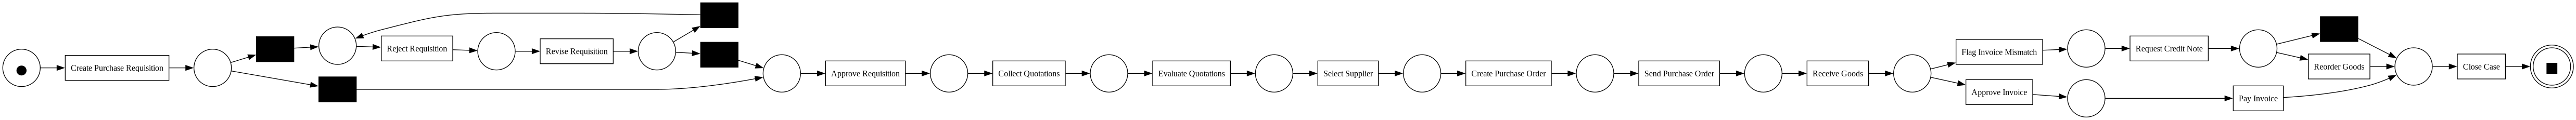

In [12]:
# Calculate and store markings:
import os
import pickle
import data_processing.petri_net_replay_markings
importlib.reload(data_processing.petri_net_replay_markings)
from data_processing.petri_net_replay_markings import InductiveMiner

# initialize the process 
miner = InductiveMiner(path_to_csv_log=event_log_location, case_id_col="case:concept:name", activity_col="concept:name", timestamp_col="time:timestamp", resource_col="org:resource")
store_loc_file_path = '../../../../data/Procurement/Petri_net/procurement.png'
net, im, fm = miner.discover_petri_net(visulaize=True,
                                       case_ids=case_ids,
                                       store_loc_file_path=store_loc_file_path)

# store discovered petri net objects next to the PNG
pkl_path = os.path.splitext(store_loc_file_path)[0] + '.pkl'
with open(pkl_path, 'wb') as f:
    pickle.dump((net, im, fm), f)

## Store "normal" tensor-datasets

In [13]:
# object to create the tensors for the dnn models and further credentials
el_loader = EventLogLoader(event_log_location=event_log_location, event_log_properties=event_log_properties, prefix_df=pref_adopt_dataframe)

In [14]:
# train tensor dataset
train_set = el_loader.get_dataset('train')

# save dataset 
torch.save(train_set, '../../../../data/Procurement/tensor_data/normal/'+result_name+'_'+str(el_loader.encoder_decoder.min_suffix_size)+'_train.pkl')

categorical tensors:   0%|          | 0/5 [00:00<?, ?it/s]

concept:name:   0%|          | 0/6500 [00:00<?, ?it/s]

org:resource:   0%|          | 0/6500 [00:00<?, ?it/s]

budget_status:   0%|          | 0/6500 [00:00<?, ?it/s]

supplier_type:   0%|          | 0/6500 [00:00<?, ?it/s]

...

seconds_in_day:   0%|          | 0/6500 [00:00<?, ?it/s]

amount:   0%|          | 0/6500 [00:00<?, ?it/s]

revision_count:   0%|          | 0/6500 [00:00<?, ?it/s]

invoice_deviation_pct:   0%|          | 0/6500 [00:00<?, ?it/s]

static categorical:   0%|          | 0/83492 [00:00<?, ?it/s]

In [15]:
# Test get sizes and others
print("Min suffix size: ", train_set.min_suffix_size)

print("Categories and encoding params for dynamic categorical and continuous values: ", train_set.all_categories)
print("Categories and encoding params for static categorical and continuous values: ", train_set.all_static_categories)

print("Dynamic categorical tensor: ", train_set.categorical_tensors[0].size())
print("Dynamic continuous tensor: ", train_set.continuous_tensors[0].size())

print("Static categorical tensor: ", train_set.static_categorical_tensor.size())
print("Static continuous tensor: ", train_set.static_continuous_tensor.size())

print("Zero padding tensor: ", train_set.zero_padding.size())
print("EOS padding tensor: ",train_set.eos_padding.size())

if isinstance(train_set.decision_data, torch.Tensor):
    print("Decision data tensor: ", train_set.decision_data.size())
else:
    print("Decision data: ", len(train_set.decision_data))
    print("Decision data: ", len(train_set.decision_data[0]) if len(train_set.decision_data) > 0 else 0)

# print(train_set.prefixes_petri_net_marking[0:3])

Min suffix size:  5
Categories and encoding params for dynamic categorical and continuous values:  ([('concept:name', 18, {'Approve Invoice': 1, 'Approve Requisition': 2, 'Close Case': 3, 'Collect Quotations': 4, 'Create Purchase Order': 5, 'Create Purchase Requisition': 6, 'EOS': 7, 'Evaluate Quotations': 8, 'Flag Invoice Mismatch': 9, 'Pay Invoice': 10, 'Receive Goods': 11, 'Reject Requisition': 12, 'Reorder Goods': 13, 'Request Credit Note': 14, 'Revise Requisition': 15, 'Select Supplier': 16, 'Send Purchase Order': 17}), ('org:resource', 22, {'Alice': 1, 'Bob': 2, 'Buyer_1': 3, 'Buyer_2': 4, 'Buyer_3': 5, 'Carol': 6, 'Clerk_1': 7, 'Clerk_2': 8, 'Clerk_3': 9, 'David': 10, 'EOS': 11, 'Eva': 12, 'Frank': 13, 'Manager_FIN_1': 14, 'Manager_FIN_2': 15, 'Manager_IT_1': 16, 'Manager_IT_2': 17, 'Manager_OPS_1': 18, 'Manager_OPS_2': 19, 'Receiver_A': 20, 'Receiver_B': 21}), ('budget_status', 4, {'EOS': 1, 'approved': 2, 'pending': 3}), ('supplier_type', 6, {'EOS': 1, 'preferred': 2, 'risky':

In [16]:
# train tensor dataset
val_set = el_loader.get_dataset('val')

# save dataset 
torch.save(val_set, '../../../../data/Procurement/tensor_data/normal/'+result_name+'_'+str(el_loader.encoder_decoder.min_suffix_size)+'_val.pkl')

categorical tensors:   0%|          | 0/5 [00:00<?, ?it/s]

concept:name:   0%|          | 0/1500 [00:00<?, ?it/s]

org:resource:   0%|          | 0/1500 [00:00<?, ?it/s]

budget_status:   0%|          | 0/1500 [00:00<?, ?it/s]

supplier_type:   0%|          | 0/1500 [00:00<?, ?it/s]

...

seconds_in_day:   0%|          | 0/1500 [00:00<?, ?it/s]

amount:   0%|          | 0/1500 [00:00<?, ?it/s]

revision_count:   0%|          | 0/1500 [00:00<?, ?it/s]

invoice_deviation_pct:   0%|          | 0/1500 [00:00<?, ?it/s]

static categorical:   0%|          | 0/19284 [00:00<?, ?it/s]

In [17]:
# Test get sizes and others
print("Min suffix size: ", val_set.min_suffix_size)

print("Categories and encoding params for dynamic categorical and continuous values: ", val_set.all_categories)
print("Categories and encoding params for static categorical and continuous values: ", val_set.all_static_categories)

print("Dynamic categorical tensor: ", val_set.categorical_tensors[0].size())
print("Dynamic continuous tensor: ", val_set.continuous_tensors[0].size())

print("Static categorical tensor: ", val_set.static_categorical_tensor.size())
print("Static continuous tensor: ", val_set.static_continuous_tensor.size())

print("Zero padding tensor: ", val_set.zero_padding.size())
print("EOS padding tensor: ",val_set.eos_padding.size())

# print("Prefix petri net replay tensor: ", len(val_set.prefixes_petri_net_marking))
# print(val_set.prefixes_petri_net_marking[0:3])

Min suffix size:  5
Categories and encoding params for dynamic categorical and continuous values:  ([('concept:name', 18, {'Approve Invoice': 1, 'Approve Requisition': 2, 'Close Case': 3, 'Collect Quotations': 4, 'Create Purchase Order': 5, 'Create Purchase Requisition': 6, 'EOS': 7, 'Evaluate Quotations': 8, 'Flag Invoice Mismatch': 9, 'Pay Invoice': 10, 'Receive Goods': 11, 'Reject Requisition': 12, 'Reorder Goods': 13, 'Request Credit Note': 14, 'Revise Requisition': 15, 'Select Supplier': 16, 'Send Purchase Order': 17}), ('org:resource', 22, {'Alice': 1, 'Bob': 2, 'Buyer_1': 3, 'Buyer_2': 4, 'Buyer_3': 5, 'Carol': 6, 'Clerk_1': 7, 'Clerk_2': 8, 'Clerk_3': 9, 'David': 10, 'EOS': 11, 'Eva': 12, 'Frank': 13, 'Manager_FIN_1': 14, 'Manager_FIN_2': 15, 'Manager_IT_1': 16, 'Manager_IT_2': 17, 'Manager_OPS_1': 18, 'Manager_OPS_2': 19, 'Receiver_A': 20, 'Receiver_B': 21}), ('budget_status', 4, {'EOS': 1, 'approved': 2, 'pending': 3}), ('supplier_type', 6, {'EOS': 1, 'preferred': 2, 'risky':

In [18]:
# train tensor dataset
test_set = el_loader.get_dataset('test')

# save dataset 
torch.save(test_set, '../../../../data/Procurement/tensor_data/normal/'+result_name+'_'+str(el_loader.encoder_decoder.min_suffix_size)+'_test.pkl')

categorical tensors:   0%|          | 0/5 [00:00<?, ?it/s]

concept:name:   0%|          | 0/2000 [00:00<?, ?it/s]

org:resource:   0%|          | 0/2000 [00:00<?, ?it/s]

budget_status:   0%|          | 0/2000 [00:00<?, ?it/s]

supplier_type:   0%|          | 0/2000 [00:00<?, ?it/s]

...

seconds_in_day:   0%|          | 0/2000 [00:00<?, ?it/s]

amount:   0%|          | 0/2000 [00:00<?, ?it/s]

revision_count:   0%|          | 0/2000 [00:00<?, ?it/s]

invoice_deviation_pct:   0%|          | 0/2000 [00:00<?, ?it/s]

static categorical:   0%|          | 0/25584 [00:00<?, ?it/s]

In [19]:
# Test get sizes and others
print("Min suffix size: ", test_set.min_suffix_size)

print("Categories and encoding params for dynamic categorical and continuous values: ", test_set.all_categories)
print("Categories and encoding params for static categorical and continuous values: ", test_set.all_static_categories)

print("Dynamic categorical tensor: ", test_set.categorical_tensors[0].size())
# print("Dynamic categorical tensor examples: ", test_set.categorical_tensors[0][10:55])
print("Dynamic continuous tensor: ", test_set.continuous_tensors[0].size())

print("Static categorical tensor: ", test_set.static_categorical_tensor.size())
print("Static continuous tensor: ", test_set.static_continuous_tensor.size())

print("Zero padding tensor: ", test_set.zero_padding.size())
print("EOS padding tensor: ",test_set.eos_padding.size())
# print("Zero padds: ", test_set.zero_padding[35:41])
# print("EOS padds: ", test_set.eos_padding[35:41])

# print("Prefix petri net replay tensor: ", len(test_set.prefixes_petri_net_marking))
# print(test_set.prefixes_petri_net_marking[0:3])

Min suffix size:  5
Categories and encoding params for dynamic categorical and continuous values:  ([('concept:name', 18, {'Approve Invoice': 1, 'Approve Requisition': 2, 'Close Case': 3, 'Collect Quotations': 4, 'Create Purchase Order': 5, 'Create Purchase Requisition': 6, 'EOS': 7, 'Evaluate Quotations': 8, 'Flag Invoice Mismatch': 9, 'Pay Invoice': 10, 'Receive Goods': 11, 'Reject Requisition': 12, 'Reorder Goods': 13, 'Request Credit Note': 14, 'Revise Requisition': 15, 'Select Supplier': 16, 'Send Purchase Order': 17}), ('org:resource', 22, {'Alice': 1, 'Bob': 2, 'Buyer_1': 3, 'Buyer_2': 4, 'Buyer_3': 5, 'Carol': 6, 'Clerk_1': 7, 'Clerk_2': 8, 'Clerk_3': 9, 'David': 10, 'EOS': 11, 'Eva': 12, 'Frank': 13, 'Manager_FIN_1': 14, 'Manager_FIN_2': 15, 'Manager_IT_1': 16, 'Manager_IT_2': 17, 'Manager_OPS_1': 18, 'Manager_OPS_2': 19, 'Receiver_A': 20, 'Receiver_B': 21}), ('budget_status', 4, {'EOS': 1, 'approved': 2, 'pending': 3}), ('supplier_type', 6, {'EOS': 1, 'preferred': 2, 'risky':